In [1]:
# Install required packages
install.packages(c(
  "palmerpenguins",
  "dplyr",
  "ggplot2",
  "moments",
  "car",
  "effectsize"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘bayestestR’, ‘insight’, ‘parameters’, ‘performance’, ‘datawizard’




In [2]:
library(palmerpenguins)
library(dplyr)
library(ggplot2)
library(moments)
library(car)
library(effectsize)


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




In [3]:
# Load dataset
data("penguins")

# Display first 6 rows
head(penguins)

# Display last 6 rows
tail(penguins)

# Structure of dataset
str(penguins)

# Number of rows and columns
dim(penguins)

# Column names
names(penguins)

# Summary statistics
summary(penguins)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Chinstrap,Dream,45.7,17.0,195,3650,female,2009
Chinstrap,Dream,55.8,19.8,207,4000,male,2009
Chinstrap,Dream,43.5,18.1,202,3400,female,2009
Chinstrap,Dream,49.6,18.2,193,3775,male,2009
Chinstrap,Dream,50.8,19.0,210,4100,male,2009
Chinstrap,Dream,50.2,18.7,198,3775,female,2009


tibble [344 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int [1:344] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


[1] 344   8

[1] "species"           "island"            "bill_length_mm"   
[4] "bill_depth_mm"     "flipper_length_mm" "body_mass_g"      
[7] "sex"               "year"

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NAs    :2       NAs    :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NAs   : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NAs    :2         NAs    :2                  

In [4]:
# Missing values in each column
colSums(is.na(penguins))

species            island    bill_length_mm     bill_depth_mm 
                0                 0                 2                 2 
flipper_length_mm       body_mass_g               sex              year 
                2                 2                11                 0

In [5]:
penguins_clean <- penguins %>%
  filter(!is.na(body_mass_g),
         !is.na(flipper_length_mm),
         !is.na(sex),
         !is.na(species))

head(penguins_clean)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007


In [6]:
body_mass <- penguins_clean$body_mass_g

mean(body_mass)
median(body_mass)
min(body_mass)
max(body_mass)
var(body_mass)
sd(body_mass)
quantile(body_mass, 0.25)
quantile(body_mass, 0.75)
IQR(body_mass)
skewness(body_mass)
kurtosis(body_mass)

[1] 4207.057

[1] 4050

[1] 2700

[1] 6300

[1] 648372.5

...

25% 
3550

75% 
4775

[1] 1225

[1] 0.4701162

[1] 2.259514

In [7]:
descriptive_stats <- data.frame(
  Statistic = c(
    "Mean",
    "Median",
    "Minimum",
    "Maximum",
    "Variance",
    "Standard Deviation",
    "First Quartile (Q1)",
    "Third Quartile (Q3)",
    "IQR",
    "Skewness",
    "Kurtosis"
  ),

  Value = c(
    mean(body_mass),
    median(body_mass),
    min(body_mass),
    max(body_mass),
    var(body_mass),
    sd(body_mass),
    quantile(body_mass, 0.25),
    quantile(body_mass, 0.75),
    IQR(body_mass),
    skewness(body_mass),
    kurtosis(body_mass)
  )
)

descriptive_stats

Statistic,Value
<chr>,<dbl>
Mean,4.207057e+03
Median,4.050000e+03
Minimum,2.700000e+03
Maximum,6.300000e+03
Variance,6.483725e+05
Standard Deviation,8.052158e+02
First Quartile (Q1),3.550000e+03
Third Quartile (Q3),4.775000e+03
IQR,1.225000e+03


In [8]:
species_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

species_stats

species,Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<fct>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,3706.164,3700,2850,4775,210332.4,458.6201,3362.5,4000,637.5,0.2770077,2.411479
Chinstrap,3733.088,3700,2700,4800,147713.5,384.3351,3487.5,3950,462.5,0.2419413,3.463681
Gentoo,5092.437,5050,3950,6300,251478.3,501.4762,4700.0,5500,800.0,0.0449965,2.242850


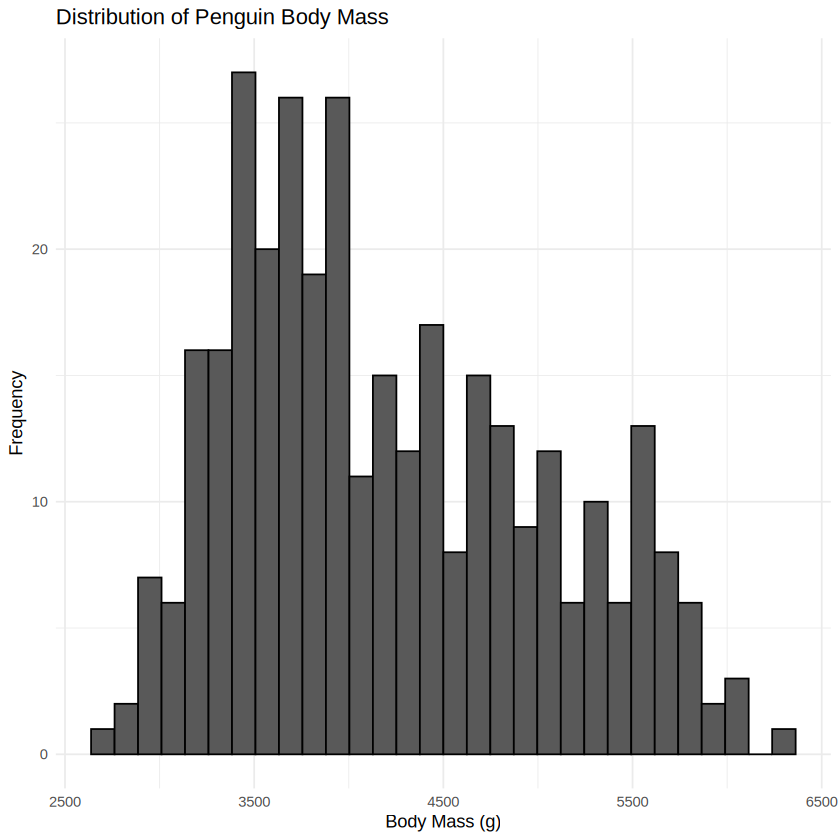

In [9]:
ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(
    bins = 30,
    color = "black"
  ) +
  labs(
    title = "Distribution of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Frequency"
  ) +
  theme_minimal()

The histogram shows the distribution of penguin body mass. The distribution is not perfectly symmetric because penguins belong to different species with different typical body masses.

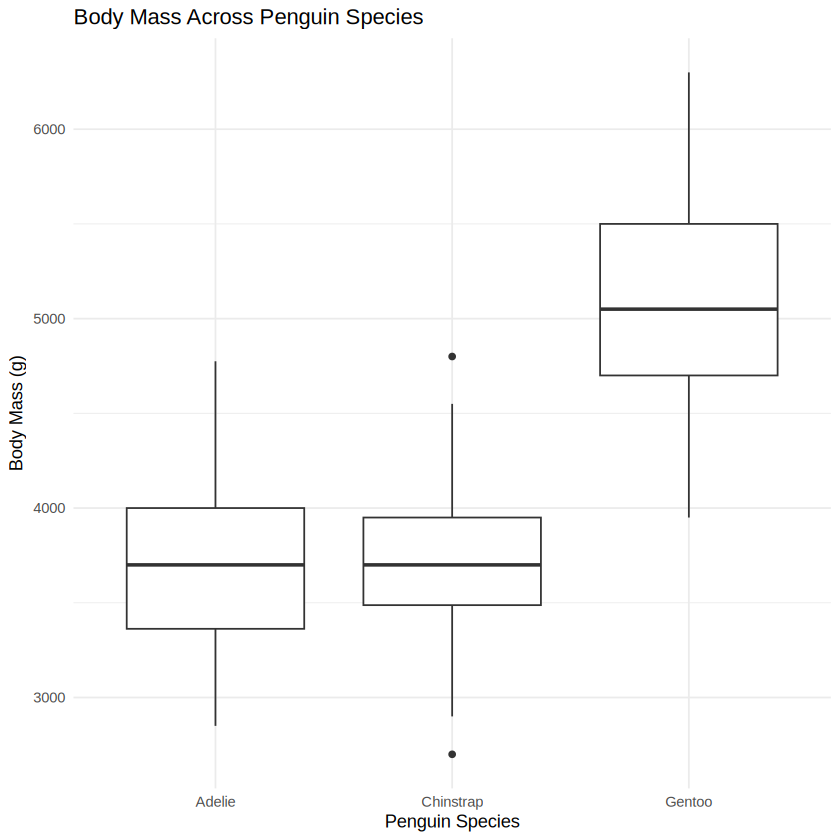

In [10]:
ggplot(penguins_clean,
       aes(x = species, y = body_mass_g)) +
  geom_boxplot() +
  labs(
    title = "Body Mass Across Penguin Species",
    x = "Penguin Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

Interpretation

The boxplot shows clear differences in body mass among the three penguin species. Gentoo penguins generally have higher body mass than Adélie and Chinstrap penguins.

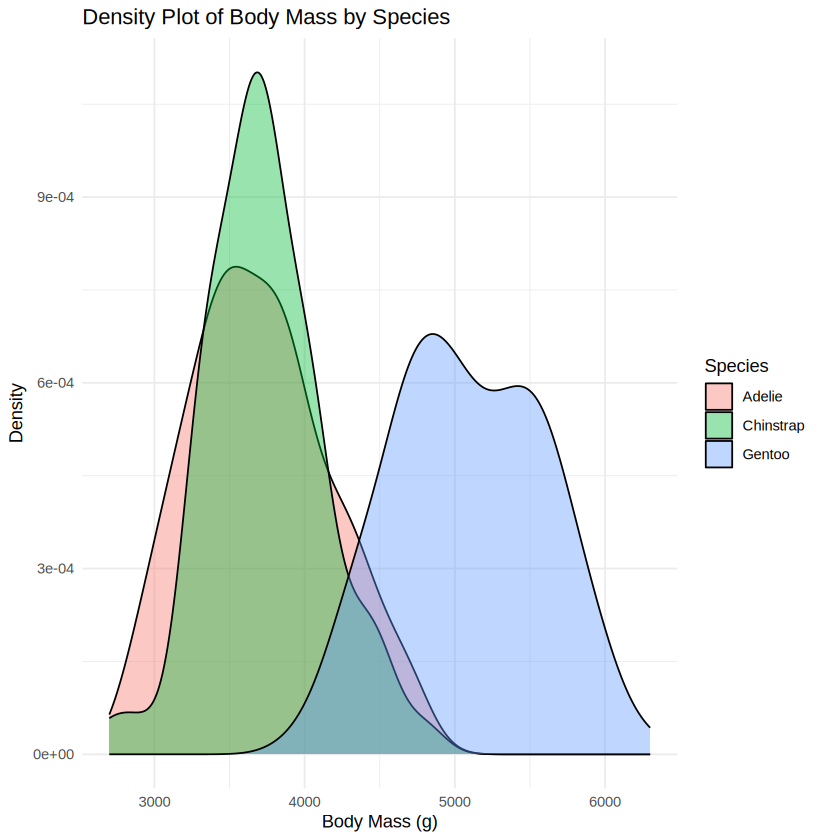

In [11]:
ggplot(penguins_clean,
       aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.4) +
  labs(
    title = "Density Plot of Body Mass by Species",
    x = "Body Mass (g)",
    y = "Density",
    fill = "Species"
  ) +
  theme_minimal()

Hypotheses
Null hypothesis

H₀: Mean body mass of male penguins = mean body mass of female penguins.

Alternative hypothesis

H₁: Mean body mass of male penguins ≠ mean body mass of female penguins.

In [14]:
male <- penguins_clean %>%
  filter(sex == "male") %>%
  pull(body_mass_g)

female <- penguins_clean %>%
  filter(sex == "female") %>%
  pull(body_mass_g)

In [15]:
length(male)
length(female)

[1] 168

[1] 165

In [16]:
mean(male)
mean(female)

[1] 4545.685

[1] 3862.273

In [17]:
shapiro.test(male)


	Shapiro-Wilk normality test

data:  male
W = 0.92504, p-value = 1.227e-07


In [18]:
shapiro.test(female)


	Shapiro-Wilk normality test

data:  female
W = 0.91931, p-value = 6.155e-08


For Shapiro-Wilk:

p > 0.05 → normality assumption is not significantly violated.
p < 0.05 → evidence that the distribution differs from normal.

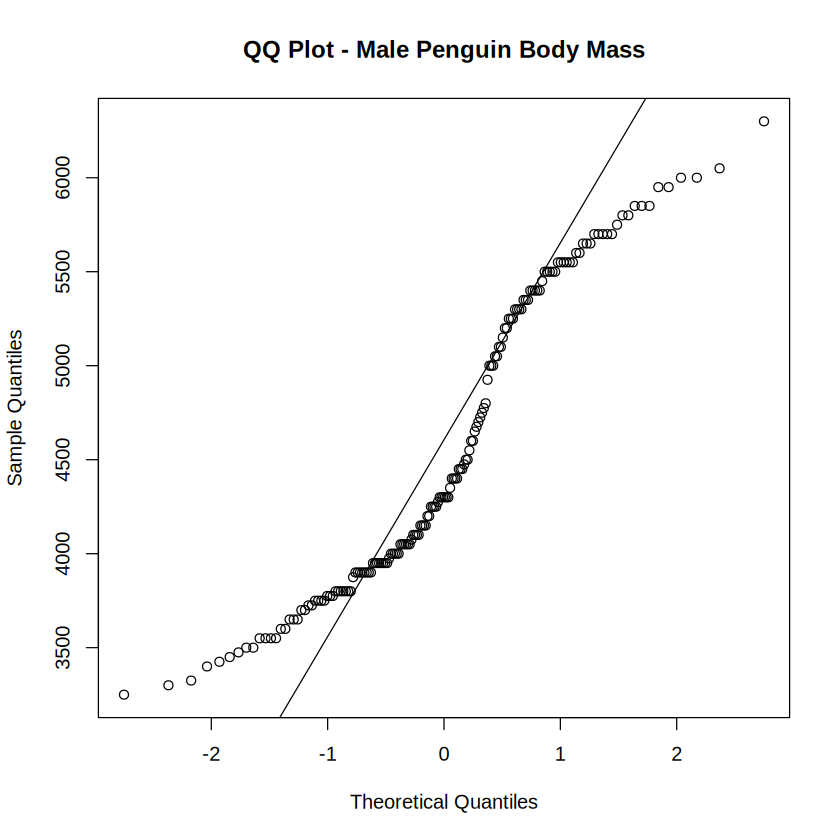

In [19]:
qqnorm(male,
       main = "QQ Plot - Male Penguin Body Mass")

qqline(male)

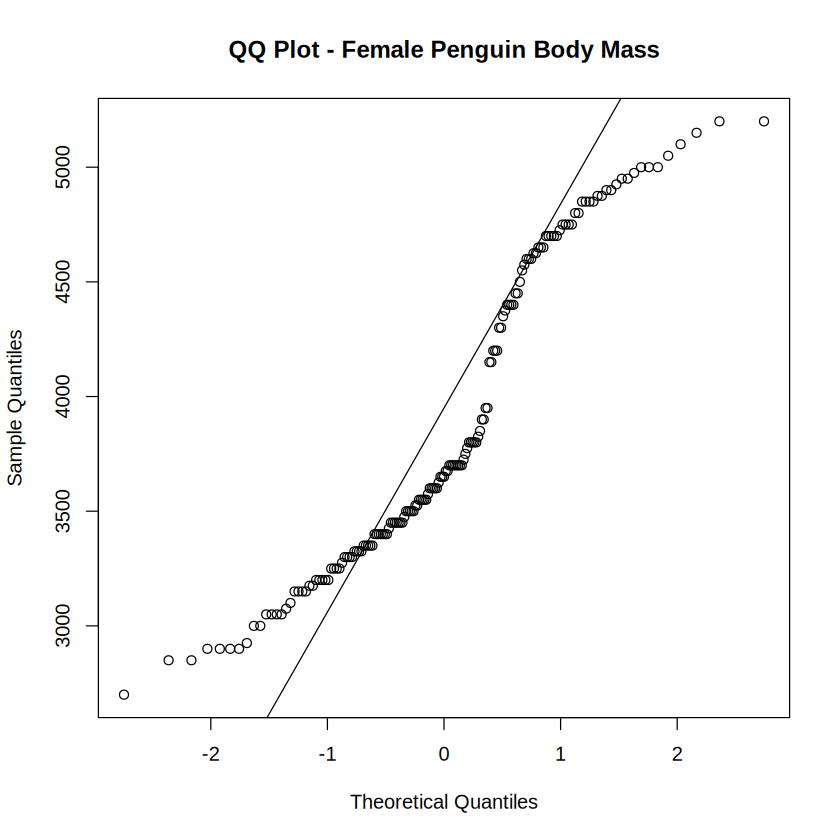

In [20]:
qqnorm(female,
       main = "QQ Plot - Female Penguin Body Mass")

qqline(female)

In [21]:
t_test_result <- t.test(
  body_mass_g ~ sex,
  data = penguins_clean,
  var.equal = FALSE
)

t_test_result


	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


In [22]:
t_test_result$p.value

[1] 4.793891e-16

In [23]:
t_test_result$conf.int

[1] -840.5783 -526.2453
attr(,"conf.level")
[1] 0.95

In [24]:
t_test_result$estimate

mean in group female   mean in group male 
            3862.273             4545.685

In [25]:
cohens_d_result <- cohens_d(
  body_mass_g ~ sex,
  data = penguins_clean
)

cohens_d_result

Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-0.9362048,0.95,-1.161904,-0.709225


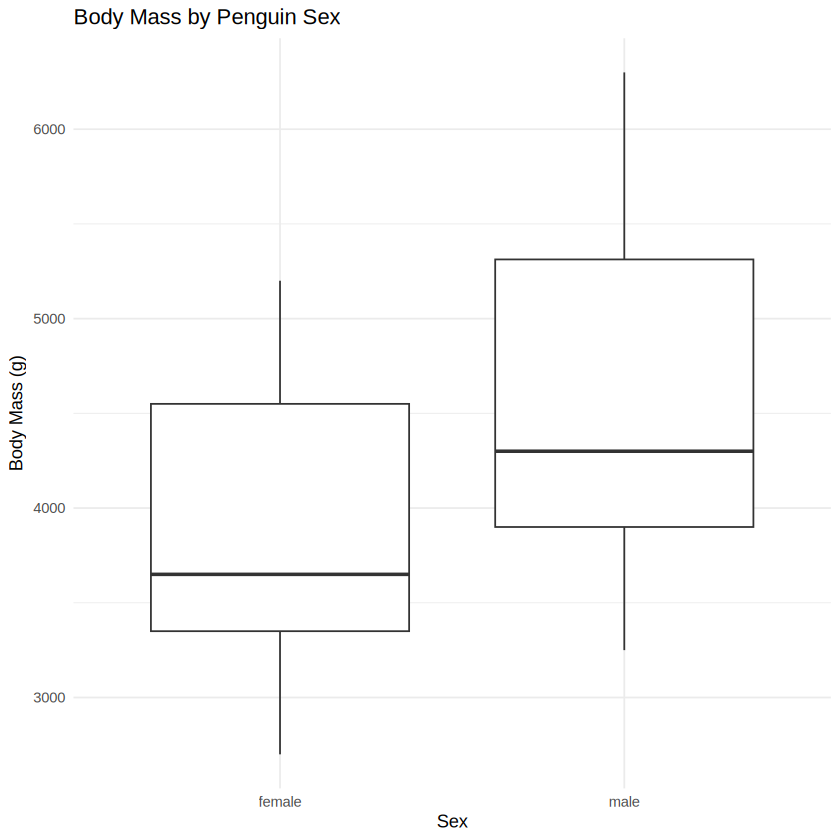

In [26]:
ggplot(penguins_clean,
       aes(x = sex, y = body_mass_g)) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Penguin Sex",
    x = "Sex",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

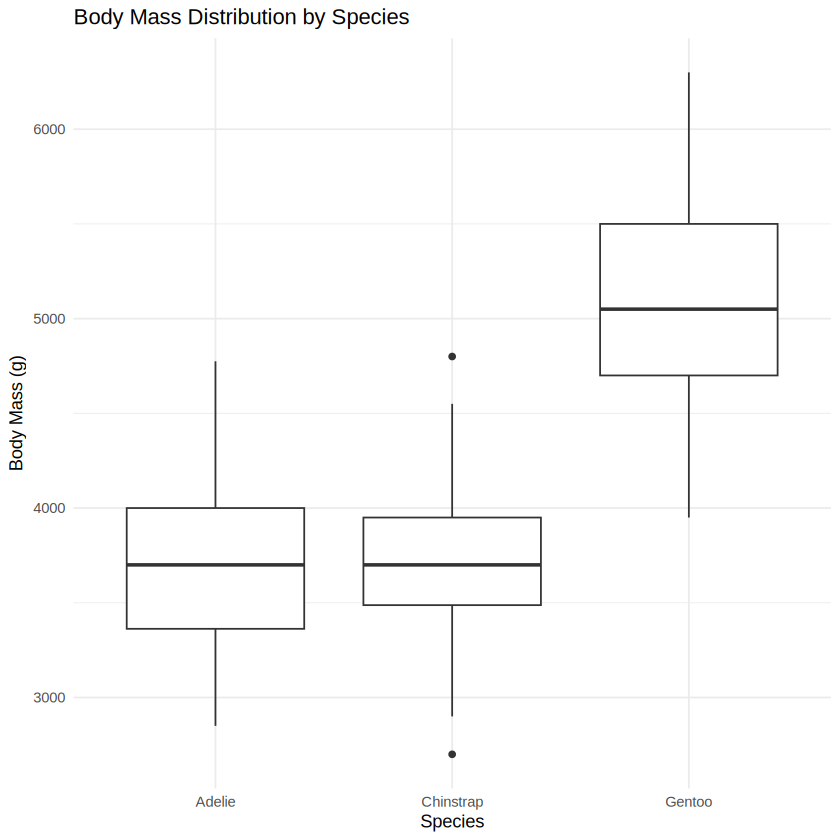

In [27]:
ggplot(penguins_clean,
       aes(x = species, y = body_mass_g)) +
  geom_boxplot() +
  labs(
    title = "Body Mass Distribution by Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

In [28]:
by(
  penguins_clean$body_mass_g,
  penguins_clean$species,
  shapiro.test
)

penguins_clean$species: Adelie

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98116, p-value = 0.04232

------------------------------------------------------------ 
penguins_clean$species: Chinstrap

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98449, p-value = 0.5605

------------------------------------------------------------ 
penguins_clean$species: Gentoo

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98606, p-value = 0.2605


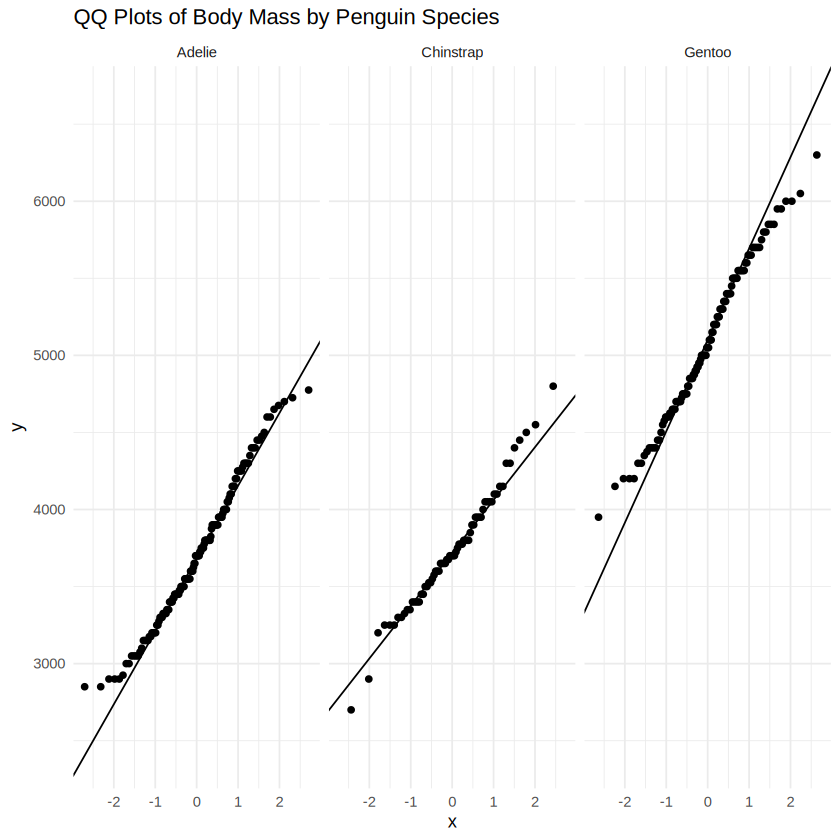

In [29]:
ggplot(penguins_clean,
       aes(sample = body_mass_g)) +
  stat_qq() +
  stat_qq_line() +
  facet_wrap(~species) +
  labs(
    title = "QQ Plots of Body Mass by Penguin Species"
  ) +
  theme_minimal()

In [30]:
leveneTest(
  body_mass_g ~ species,
  data = penguins_clean
)

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.134899,0.006367054
,330,NA,NA


In [31]:
anova_model <- aov(
  body_mass_g ~ species,
  data = penguins_clean
)

summary(anova_model)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [32]:
anova_summary <- summary(anova_model)

anova_summary[[1]]$`F value`

[1] 341.8949       NA

In [33]:
anova_summary[[1]]$`Pr(>F)`

[1] 3.744505e-81           NA

In [34]:
tukey_result <- TukeyHSD(anova_model)

tukey_result

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


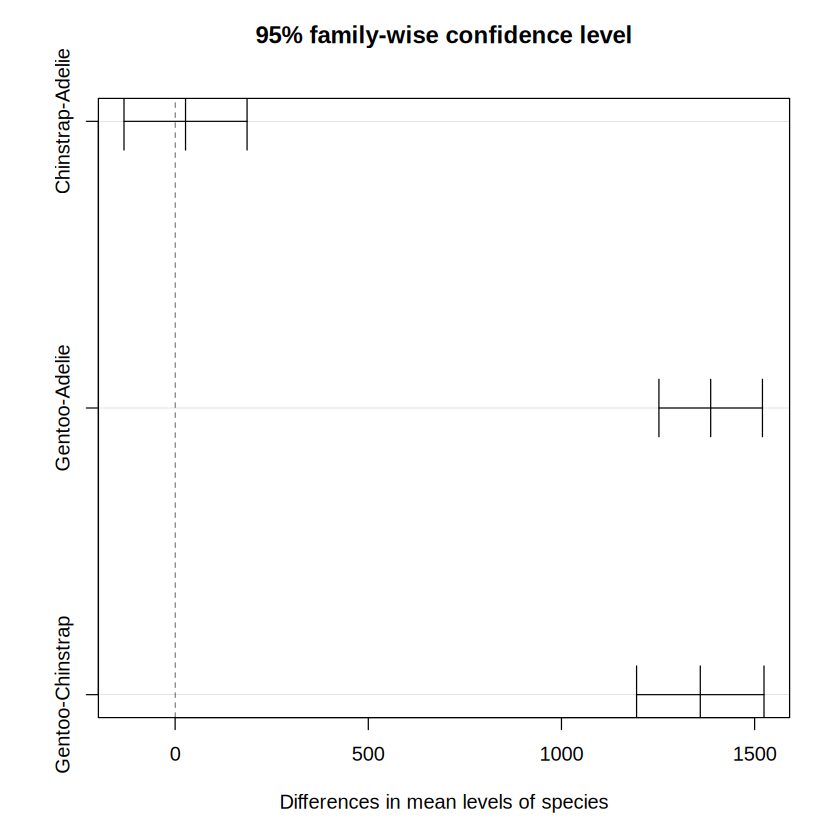

In [35]:
plot(tukey_result)

In [36]:
kruskal_result <- kruskal.test(
  body_mass_g ~ species,
  data = penguins_clean
)

kruskal_result


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


In [37]:
kruskal_result$p.value

[1] 8.836877e-47

In [38]:
cat("ANOVA p-value:",
    anova_summary[[1]]$`Pr(>F)`[1],
    "\n")

cat("Kruskal-Wallis p-value:",
    kruskal_result$p.value,
    "\n")

ANOVA p-value: 3.744505e-81 
Kruskal-Wallis p-value: 8.836877e-47 


In [39]:
two_way_model <- aov(
  body_mass_g ~ species * sex,
  data = penguins_clean
)

summary(two_way_model)

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

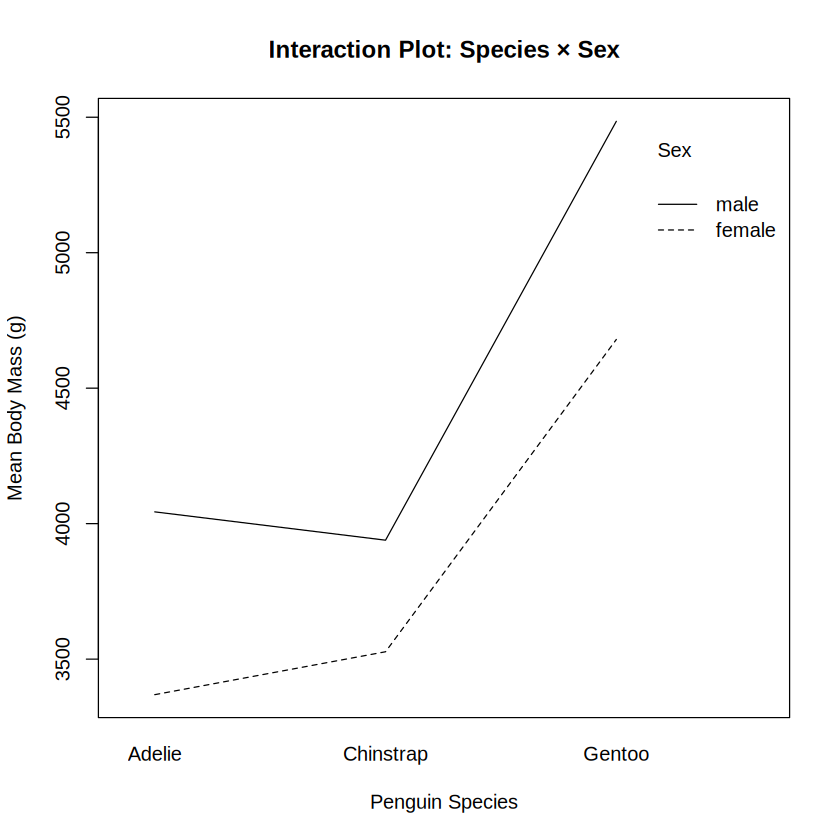

In [40]:
interaction.plot(
  x.factor = penguins_clean$species,
  trace.factor = penguins_clean$sex,
  response = penguins_clean$body_mass_g,
  xlab = "Penguin Species",
  ylab = "Mean Body Mass (g)",
  trace.label = "Sex",
  main = "Interaction Plot: Species × Sex"
)

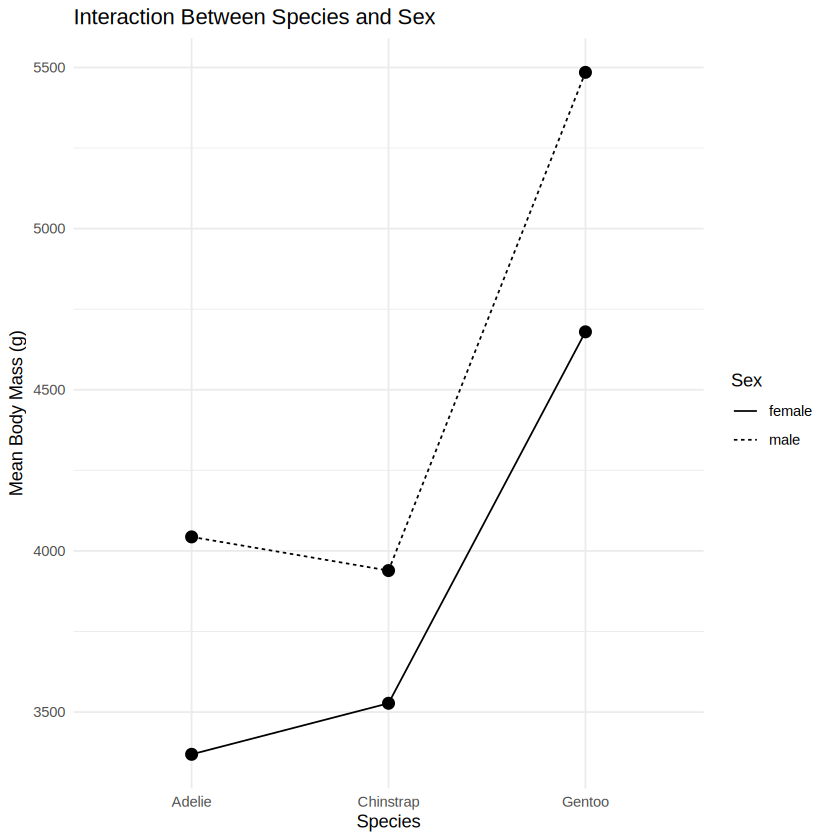

In [41]:
ggplot(
  penguins_clean,
  aes(
    x = species,
    y = body_mass_g,
    group = sex,
    linetype = sex
  )
) +
  stat_summary(
    fun = mean,
    geom = "line"
  ) +
  stat_summary(
    fun = mean,
    geom = "point",
    size = 3
  ) +
  labs(
    title = "Interaction Between Species and Sex",
    x = "Species",
    y = "Mean Body Mass (g)",
    linetype = "Sex"
  ) +
  theme_minimal()

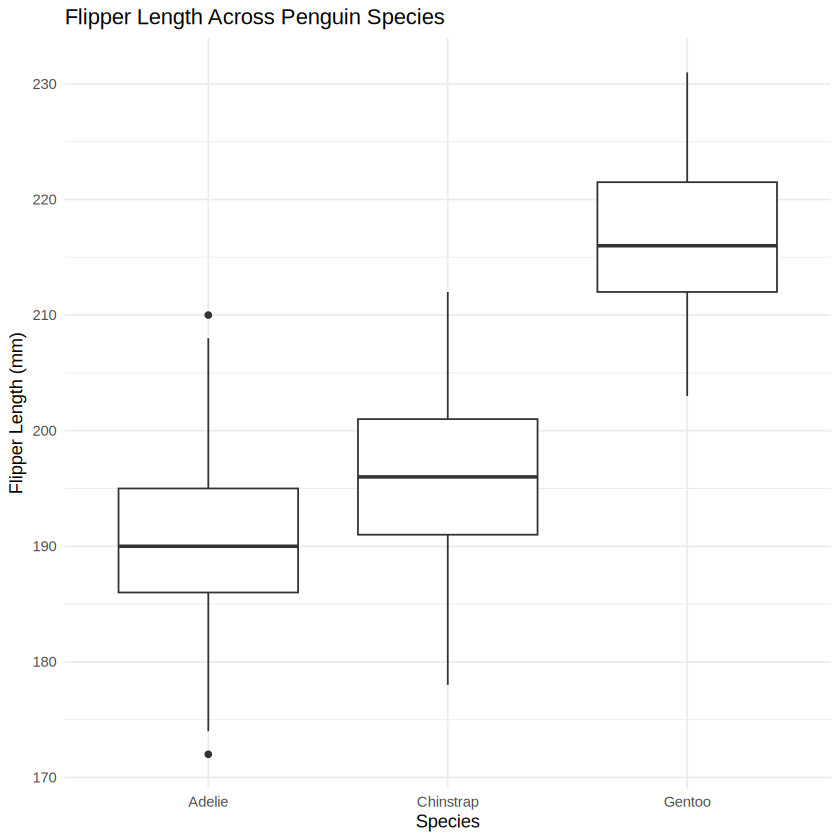

In [42]:
ggplot(
  penguins_clean,
  aes(x = species, y = flipper_length_mm)
) +
  geom_boxplot() +
  labs(
    title = "Flipper Length Across Penguin Species",
    x = "Species",
    y = "Flipper Length (mm)"
  ) +
  theme_minimal()

In [43]:
flipper_anova <- aov(
  flipper_length_mm ~ species,
  data = penguins_clean
)

summary(flipper_anova)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [44]:
TukeyHSD(flipper_anova)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins_clean)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0


In [45]:
kruskal_flipper <- kruskal.test(
  flipper_length_mm ~ species,
  data = penguins_clean
)

kruskal_flipper


	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 237.35, df = 2, p-value < 2.2e-16


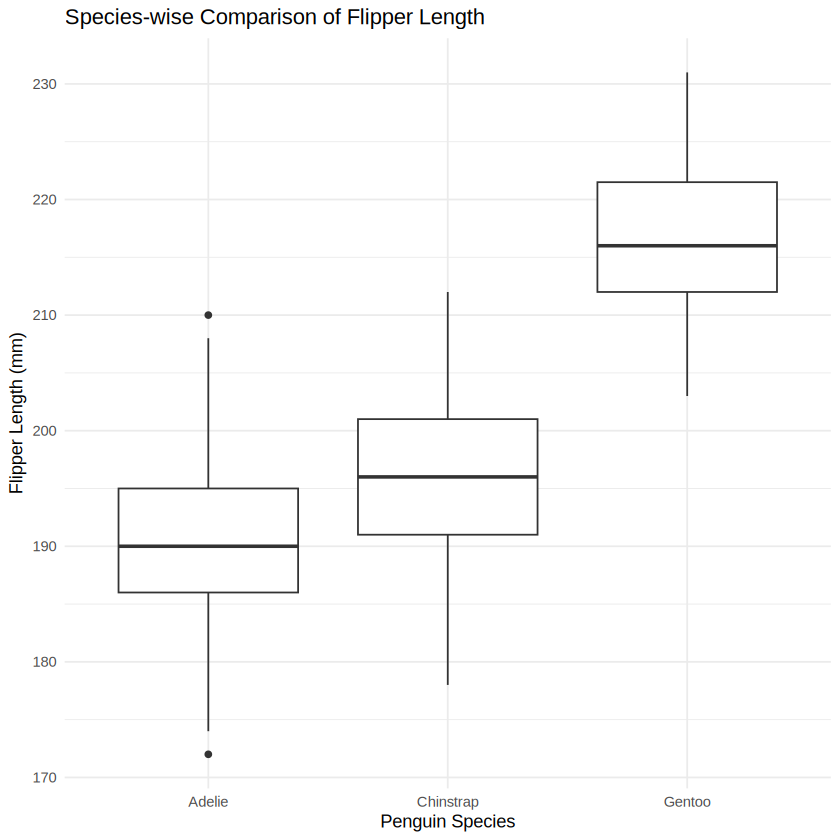

In [46]:
ggplot(
  penguins_clean,
  aes(x = species, y = flipper_length_mm)
) +
  geom_boxplot() +
  labs(
    title = "Species-wise Comparison of Flipper Length",
    x = "Penguin Species",
    y = "Flipper Length (mm)"
  ) +
  theme_minimal()

In [47]:
cat("====================================\n")
cat("STATISTICAL ANALYSIS SUMMARY\n")
cat("====================================\n\n")

cat("Overall Mean Body Mass:",
    mean(penguins_clean$body_mass_g), "g\n")

cat("Overall Median Body Mass:",
    median(penguins_clean$body_mass_g), "g\n\n")

cat("Male Mean Body Mass:",
    mean(male), "g\n")

cat("Female Mean Body Mass:",
    mean(female), "g\n\n")

cat("T-Test p-value:",
    t_test_result$p.value, "\n")

cat("Cohen's d:\n")
print(cohens_d_result)

cat("\nOne-Way ANOVA:\n")
print(summary(anova_model))

cat("\nTukey HSD:\n")
print(tukey_result)

cat("\nKruskal-Wallis Test:\n")
print(kruskal_result)

cat("\nTwo-Way ANOVA:\n")
print(summary(two_way_model))

cat("\nFlipper Length ANOVA:\n")
print(summary(flipper_anova))

cat("\nFlipper Length Kruskal-Wallis:\n")
print(kruskal_flipper)

STATISTICAL ANALYSIS SUMMARY

Overall Mean Body Mass: 4207.057 g
Overall Median Body Mass: 4050 g

Male Mean Body Mass: 4545.685 g
Female Mean Body Mass: 3862.273 g

T-Test p-value: 4.793891e-16 
Cohen's d:
Cohen's d |         95% CI
--------------------------
-0.94     | [-1.16, -0.71]

- Estimated using pooled SD.
One-Way ANOVA:
             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Tukey HSD:
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


Kruskal-Wallis Test:

	Kruskal-Wallis rank su

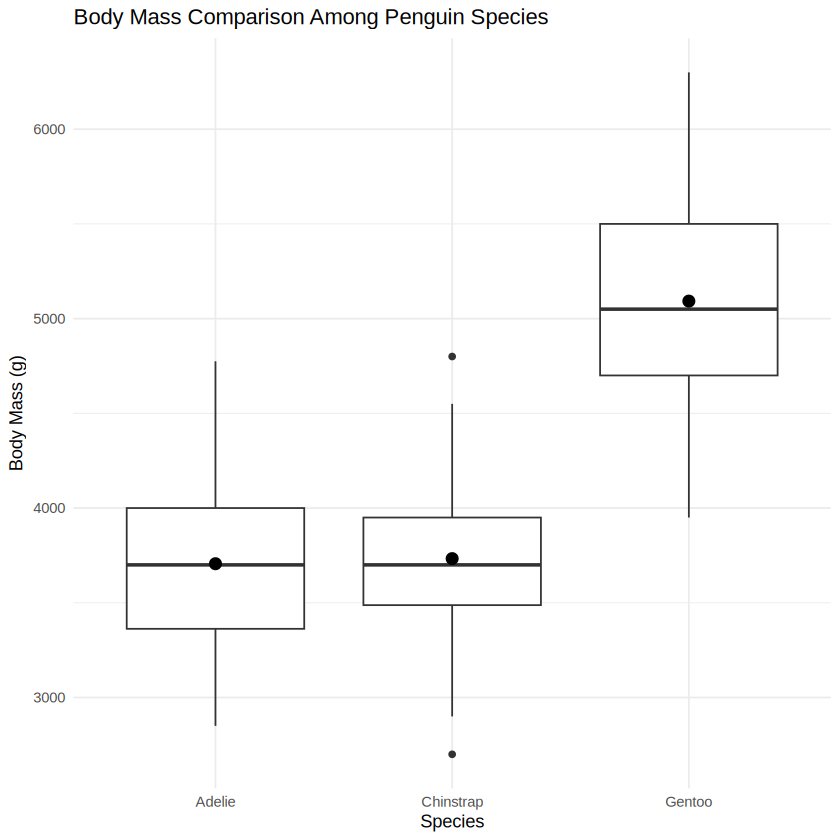

In [48]:
ggplot(
  penguins_clean,
  aes(x = species, y = body_mass_g)
) +
  geom_boxplot() +
  stat_summary(
    fun = mean,
    geom = "point",
    size = 3
  ) +
  labs(
    title = "Body Mass Comparison Among Penguin Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

###Conclusion:

The Palmer Penguins dataset was statistically analyzed using descriptive
statistics, hypothesis testing, ANOVA and non-parametric methods.

Descriptive analysis showed differences in body mass among the three penguin
species. The independent two-sample t-test was used to compare male and
female body masses. The p-value and 95% confidence interval were examined
to determine statistical significance, while Cohen's d was used to measure
the magnitude of the difference.

One-way ANOVA was performed to investigate differences in mean body mass
among Adelie, Chinstrap and Gentoo penguins. Normality and homogeneity of
variance assumptions were checked using Shapiro-Wilk/QQ plots and Levene's
test. When the ANOVA was significant, Tukey's HSD test was used to identify
the specific species pairs that differed.

The Kruskal-Wallis test was also performed as a non-parametric alternative.
Its result was compared with the ANOVA result.

A two-way ANOVA was performed to evaluate the effects of species, sex and
their interaction on body mass.

Finally, flipper length was analyzed across the three species. The results
were compared with the body-mass analysis to determine whether flipper
length showed a similar species-wise pattern.